# 01 — Data Preparation
Dataset: PAD-UFES-20 | Paper: arXiv:2205.15442

Mục tiêu:
- Load ảnh từ `imgs_part_1/2/3`
- Hiển thị phân phối class (6 loại)
- Chuẩn hoá metadata (StandardScaler + One-Hot)
- Lưu `processed_metadata.csv` để các notebook sau dùng

In [2]:
import sys, os
sys.path.insert(0, '..')
from skin_pipeline.utils import prepare_metadata, CLASSES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

DATA_DIR  = os.path.expanduser('~/.cache/kagglehub/datasets/mahdavi1202/skin-cancer/versions/1')
OUT_CSV   = 'processed_metadata.csv'

## 1. Load & Preprocess

In [3]:
df, feature_cols = prepare_metadata(DATA_DIR, output_csv=OUT_CSV)
print(f'Total samples: {len(df)}')
print(f'Total clinical features: {len(feature_cols)}')
df[['img_id','diagnostic','diagnostic_idx']].head()

Found 2298 images.
Metadata rows matched to images: 2298
Saved to: processed_metadata.csv
Total samples: 2298
Total clinical features: 88


,img_id,diagnostic,diagnostic_idx
0,PAT_1516_1765_530.png,NEV,3
1,PAT_46_881_939.png,BCC,1
2,PAT_1545_1867_547.png,ACK,0
3,PAT_1989_4061_934.png,ACK,0
4,PAT_684_1302_588.png,BCC,1


## 2. Phân phối Class 

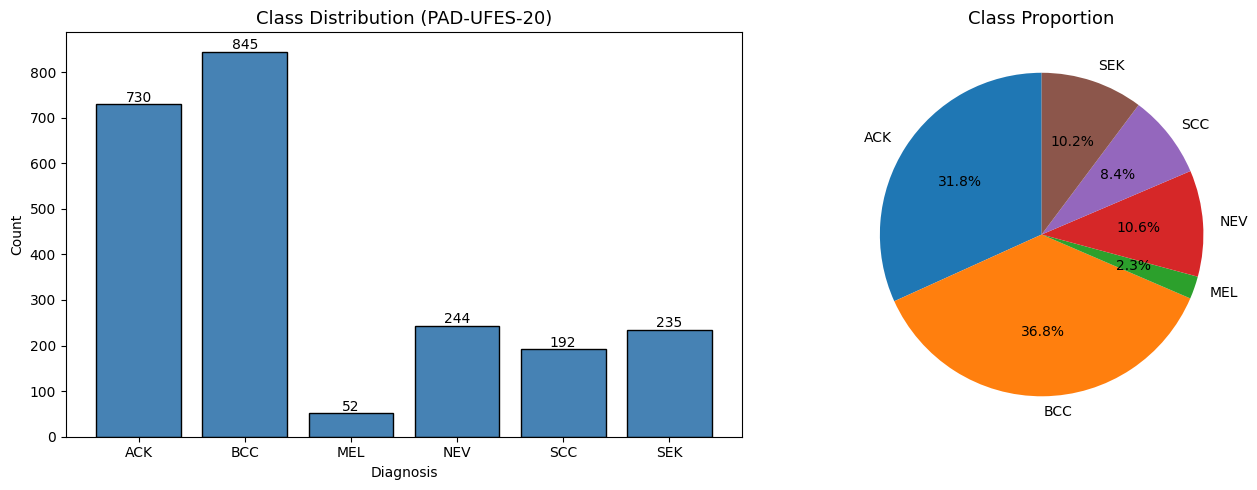


Reference (paper):
  ACK: 730
  BCC: 845
  MEL: 52
  NEV: 244
  SCC: 192
  SEK: 235


In [4]:
counts = df['diagnostic'].value_counts().reindex(CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution (PAD-UFES-20)', fontsize=13)
axes[0].set_xlabel('Diagnosis'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.show()
print('\nReference (paper):')
ref = {'ACK':730,'BCC':845,'MEL':52,'NEV':244,'SCC':192,'SEK':235}
for k,v in ref.items(): print(f'  {k}: {v}')

## 3. Xem mẫu ảnh theo class

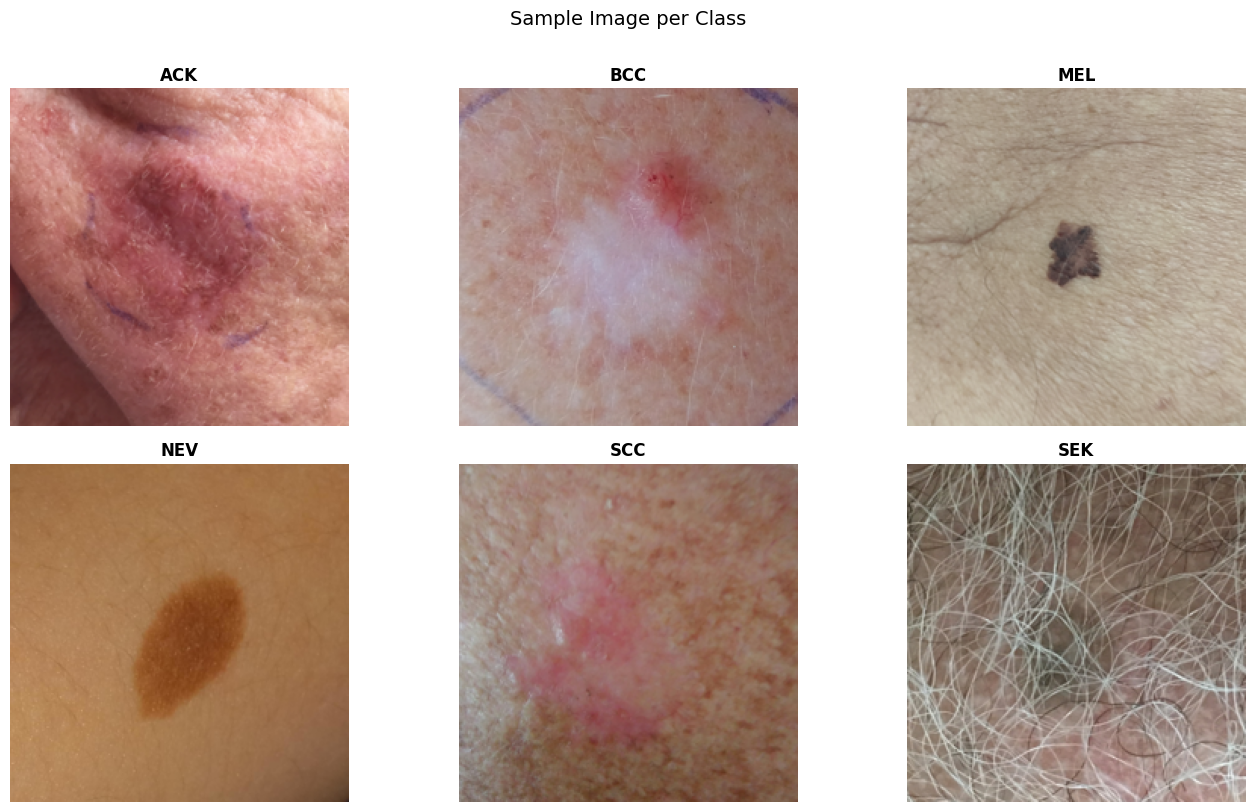

In [5]:
from pathlib import Path
from PIL import Image
import numpy as np

# Build img_map
img_map = {f.name: str(f) for f in Path(DATA_DIR).rglob('*.*') if f.suffix.lower() in {'.png','.jpg'}}

raw_df = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, cls in zip(axes.flat, CLASSES):
    row = raw_df[raw_df['diagnostic'] == cls].iloc[0]
    img = Image.open(img_map[row['img_id']]).convert('RGB').resize((224,224))
    ax.imshow(np.array(img))
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Image per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Kiểm tra Missing Values

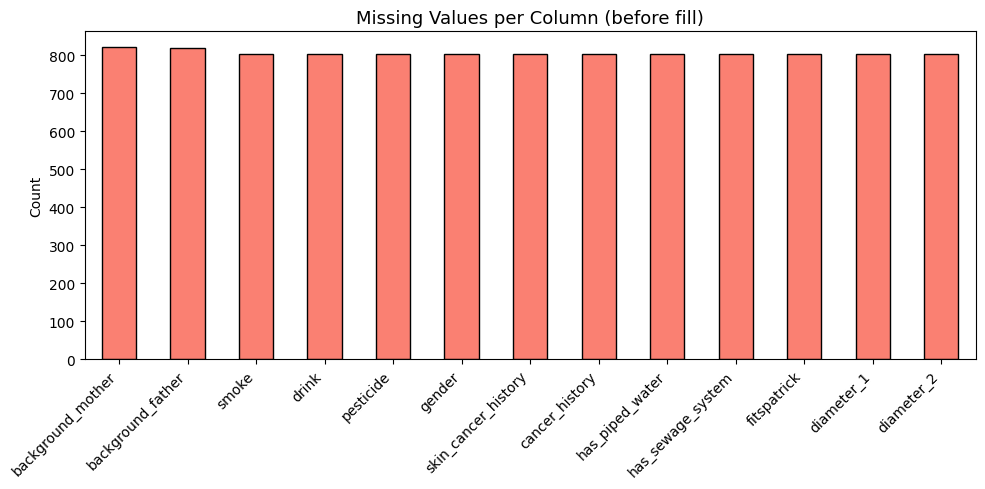


processed_metadata.csv saved ✓


In [6]:
raw_df2 = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
missing = raw_df2.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Missing Values per Column (before fill)', fontsize=13)
plt.ylabel('Count'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print('\nprocessed_metadata.csv saved ✓')